In [1]:
# Set the path to include the project root and change working directory
import sys
sys.path.append("/Users/hardikchauhan/fake-news-detector")
import os
os.chdir("/Users/hardikchauhan/fake-news-detector")

# Fake News Detector - EDA and Modeling

This notebook explores the fake news dataset and builds a classification model.

## Steps:
1. Load and explore the dataset
2. Text preprocessing
3. Feature engineering (TF-IDF)
4. Model training and evaluation
5. Error analysis
6. Model explainability with LIME
7. Saving the model and vectorizer

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_data, preprocess_pipeline
import re
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

# Load dataset

NOTE: You need to download the dataset from Kaggle first:
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
Place Fake.csv and True.csv in the data/ directory

In [3]:
# Uncomment and run after downloading data:
df = load_data('data/Fake.csv', 'data/True.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (44898, 6)


,title,text,subject,date,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...


# Sample Data Structure (for reference)

Once you have the data, it will have columns like:
- : News headline
- : Article body
- : News topic
- Sat Sep  5 00:22:27 IST 2026: Publication date
- : 0 for fake, 1 for real (added during loading)

In [4]:
# Basic info
print(df.info())
print(f"\nFake news count: {df['label'].value_counts()[0]}")
print(f"Real news count: {df['label'].value_counts()[1]}")

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
 5   content  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB
None

Fake news count: 23481
Real news count: 21417

Missing values:
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64


## Text length analysis

We'll look at the length of the text and content (title + text).

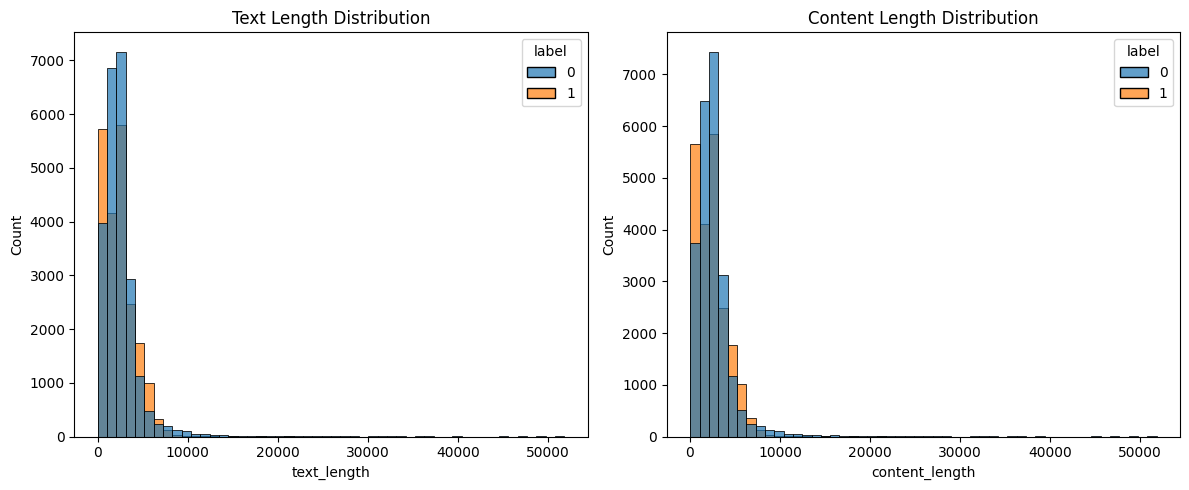

In [5]:
# Text length analysis
df['text_length'] = df['text'].str.len()
df['content_length'] = df['content'].str.len()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='text_length', hue='label', bins=50, alpha=0.7)
plt.title('Text Length Distribution')
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='content_length', hue='label', bins=50, alpha=0.7)
plt.title('Content Length Distribution')
plt.tight_layout()
plt.show()

## Text Preprocessing

We'll apply our preprocessing pipeline to the content column.

In [6]:
# Apply preprocessing
df['cleaned_content'] = df['content'].apply(preprocess_pipeline)
df[['content', 'cleaned_content']].head()

,content,cleaned_content
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump send embarrass new year’ eve mess...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk brag trump staffer start russian collus ...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clark becom internet joke threat...
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsess even obama’ name code websit imag...
4,Pope Francis Just Called Out Donald Trump Dur...,pope franci call donald trump christma speech ...


## Feature Engineering: TF-IDF

Convert text to numerical features using TF-IDF vectorization.

In [7]:
# From sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Prepare features and target
X = df['cleaned_content']
y = df['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Try different TF-IDF configurations
tfidf_configs = [
    {"max_features": 5000, "ngram_range": (1, 1), "name": "Unigram_5k"},
    {"max_features": 5000, "ngram_range": (1, 2), "name": "Bigram_5k"},
    {"max_features": 10000, "ngram_range": (1, 2), "name": "Bigram_10k"},
    {"max_features": 5000, "ngram_range": (1, 3), "name": "Trigram_5k"}
]

# Store results
results = []

for config in tfidf_configs:
    print(f"\n{'='*50}")
    print(f"Testing TF-IDF config: {config['name']}")
    print(f"{'='*50}")

    # TF-IDF Vectorization
    tfidf = TfidfVectorizer(max_features=config['max_features'],
                           ngram_range=config['ngram_range'])
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    print(f"Features: {X_train_tfidf.shape[1]}")

    # Try different models
    models = [
        ("Logistic Regression", LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')),
        ("SVM", SVC(random_state=42, probability=True, class_weight='balanced')),
        ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
        ("Gradient Boosting", GradientBoostingClassifier(random_state=42))
    ]

    for model_name, model in models:
        # Train model
        model.fit(X_train_tfidf, y_train)

        # Predictions
        y_pred = model.predict(X_test_tfidf)
        y_pred_proba = model.predict_proba(X_test_tfidf)

        # Evaluate
        accuracy = accuracy_score(y_test, y_pred)

        # Store results
        results.append({
            'tfidf_config': config['name'],
            'model': model_name,
            'accuracy': accuracy,
            'tfidf_object': tfidf,
            'model_object': model
        })

        print(f"{model_name}: Accuracy = {accuracy:.4f}")

# Find best performing model
best_result = max(results, key=lambda x: x['accuracy'])
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_result['model']} with {best_result['tfidf_config']}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"{'='*60}")

# Use the best model and vectorizer for further analysis
best_tfidf = best_result['tfidf_object']
best_model = best_result['model_object']

# Transform data with best TF-IDF
X_train_best = best_tfidf.transform(X_train)
X_test_best = best_tfidf.transform(X_test)

# Get predictions from best model
y_pred_best = best_model.predict(X_test_best)
y_pred_proba_best = best_model.predict_proba(X_test_best)

print(f"\nBest model performance details:")
print(classification_report(y_test, y_pred_best, target_names=['Fake', 'Real']))

Training set size: 35918
Test set size: 8980

Testing TF-IDF config: Unigram_5k
Features: 5000
Logistic Regression: Accuracy = 0.9882
SVM: Accuracy = 0.9947
Random Forest: Accuracy = 0.9980
Gradient Boosting: Accuracy = 0.9954

Testing TF-IDF config: Bigram_5k
Features: 5000
Logistic Regression: Accuracy = 0.9898
SVM: Accuracy = 0.9949
Random Forest: Accuracy = 0.9986
Gradient Boosting: Accuracy = 0.9960

Testing TF-IDF config: Bigram_10k
Features: 10000
Logistic Regression: Accuracy = 0.9902
SVM: Accuracy = 0.9955
Random Forest: Accuracy = 0.9983
Gradient Boosting: Accuracy = 0.9959

Testing TF-IDF config: Trigram_5k
Features: 5000
Logistic Regression: Accuracy = 0.9900
SVM: Accuracy = 0.9950
Random Forest: Accuracy = 0.9981
Gradient Boosting: Accuracy = 0.9959

BEST MODEL: Random Forest with Bigram_5k
Accuracy: 0.9986

Best model performance details:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00   

## Model Training

We'll compare Logistic Regression and Naive Bayes classifiers.

In [8]:
# Train Logistic Regression with balanced class weights to counter bias
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)
y_pred_proba_lr = lr_model.predict_proba(X_test_tfidf)

# Evaluate
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Fake', 'Real']))

Logistic Regression Accuracy: 0.9900

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [9]:
# Train Naive Bayes for comparison
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

# Compare models
print(f"\nAccuracy Comparison:")
print(f"Logistic Regression: {lr_accuracy:.4f}")
print(f"Naive Bayes: {nb_accuracy:.4f}")


Accuracy Comparison:
Logistic Regression: 0.9900
Naive Bayes: 0.9512


## Confusion Matrix

Let's visualize the performance of our best model.

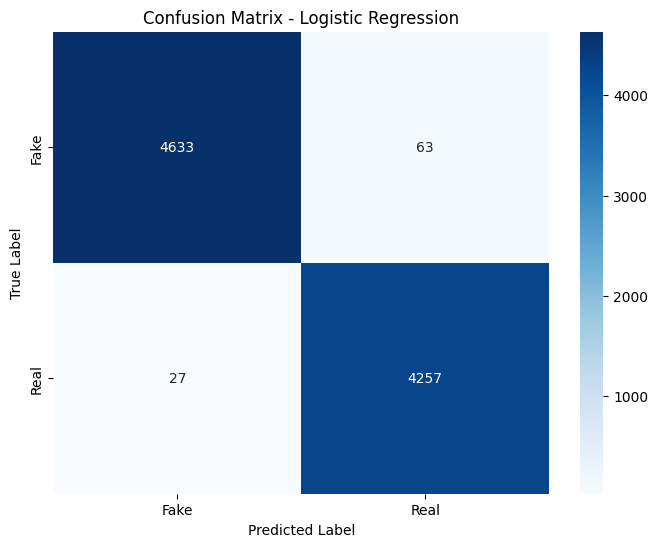

In [10]:
# Plot confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=['Fake', 'Real'],
             yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Error Analysis

Let's look at some examples the model got wrong to understand its limitations.

In [11]:
# Find misclassified examples
misclassified_idx = y_test != y_pred_lr
X_test_misclassified = X_test[misclassified_idx]
y_test_misclassified = y_test[misclassified_idx]
y_pred_misclassified = y_pred_lr[misclassified_idx]

print(f"Number of misclassified samples: {len(X_test_misclassified)}")

# Show a few examples
for i in range(min(3, len(X_test_misclassified))):
    print(f"\nExample {i+1}:")
    print(f"True label: {'Real' if y_test_misclassified.iloc[i] == 1 else 'Fake'}")
    print(f"Predicted: {'Real' if y_pred_misclassified[i] == 1 else 'Fake'}")
    print(f"Text preview: {X_test_misclassified.iloc[i][:200]}...")

Number of misclassified samples: 90

Example 1:
True label: Fake
Predicted: Real
Text preview: break trump pick penc vp…whi could yuge conserv could yuge news conserv fenc trumpgov mike penc drop reelect bid indiana becom donald trump run mateindystar confirm trump plan announc penc select vice...

Example 2:
True label: Real
Predicted: Fake
Text preview: highlight british pm may main comment brexit florenc itali reuter british prime minist theresa may set plan futur tie european union speech hope help spur negoti countri divorc bloc highlight speech f...

Example 3:
True label: Real
Predicted: Fake
Text preview: trump washington foreign polici speech reuter us republican presidenti frontrunn donald trump deliv major foreign polici speech wednesday vow alway put america first follow highlight address “no count...


## Model Explainability with LIME

Let's use LIME (Local Interpretable Model-agnostic Explanations) to understand what words are driving our predictions.

In [12]:
# Import LIME
from lime.lime_text import LimeTextExplainer

# Define prediction function for LIME (same preprocessing as training)
def predict_proba_lime(texts):
    # texts is a list of raw text strings
    cleaned = [preprocess_pipeline(text) for text in texts]
    vectorized = tfidf.transform(cleaned)
    return lr_model.predict_proba(vectorized)

# Create explainer
explainer = LimeTextExplainer(class_names=['Fake', 'Real'])

# Explain a few predictions
print("Explaining predictions for a few test samples...")
for i in range(min(5, len(X_test))):
    exp = explainer.explain_instance(
        X_test.iloc[i],
        predict_proba_lime,
        num_features=6
    )
    print(f"\nSample {i+1}:")
    print(f"True label: {'Real' if y_test.iloc[i] == 1 else 'Fake'}")
    print(f"Predicted: {'Real' if lr_model.predict(X_test_tfidf[i:i+1])[0] == 1 else 'Fake'}")
    print("Top words contributing to prediction:")
    for word, weight in exp.as_list():
        print(f"  {word}: {weight:.4f}")

Explaining predictions for a few test samples...

Sample 1:
True label: Real
Predicted: Real
Top words contributing to prediction:
  reuter: 0.2581
  said: 0.1394
  friday: 0.0624
  us: 0.0623
  stori: -0.0455
  presidentelect: 0.0444

Sample 2:
True label: Real
Predicted: Real
Top words contributing to prediction:
  reuter: 0.3597
  fbi: -0.1643
  washington: 0.1577
  trump: -0.1140
  obama: -0.1033
  presid: -0.0724

Sample 3:
True label: Fake
Predicted: Fake
Top words contributing to prediction:
  racist: -0.0246
  law: 0.0181
  claim: -0.0169
  never: -0.0169
  even: -0.0163
  flag: -0.0157

Sample 4:
True label: Real
Predicted: Real
Top words contributing to prediction:
  said: 0.1609
  reuter: 0.0552
  china: 0.0528
  parti: 0.0365
  wednesday: 0.0353
  imag: -0.0318

Sample 5:
True label: Real
Predicted: Real
Top words contributing to prediction:
  said: 0.3961
  reuter: 0.1245
  year: 0.0453
  entir: -0.0312
  like: -0.0249
  turn: -0.0247


# Saving the Model and Vectorizer

For deployment, we'll save our trained model and TF-IDF vectorizer.

In [13]:
# Import joblib for saving
import joblib

# Save the model and vectorizer
joblib.dump(lr_model, 'src/fake_news_model.pkl')
joblib.dump(tfidf, 'src/tfidf_vectorizer.pkl')
print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
